In [21]:
import numpy as np

import Kea
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import spectra_base
from Kea.utils import plotting, funcs
plotting.modify_rc()

import astropy.units as u
import astropy.constants as c

import matplotlib as mpl
import matplotlib.pyplot as plt

In [22]:

## Coma cluster ymap beta profile parameters [Khatri.Gaspari16]
y0 = 65.5e-6
thetac = (419.6*u.kpc).value
beta_khatri = 1.07
beta = 2.*beta_khatri/3.

## Resolution parameters
N = 256
D = 2
L = (2.*2400.*u.kpc).value

twopi = 2.*np.pi
dk = twopi/L
dx = L/N
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]


In [23]:
## Generate mean Beta profile
grid = np.indices(grid_dims)
pos = [n//2-1 for n in grid_dims]
r = np.linalg.norm([grid[i,...] - pos[i] for i in range(len(grid_dims))], axis=0)*dx
ym = funcs.beta_func(grid_dims, y0, thetac/dx, beta, pos)
_r, ym_avg, _ = statistics_base.bin_data(r, ym, np.nanmean)
_r, ym_std, _ = statistics_base.bin_data(r, ym, np.nanstd)

(100, 3000)

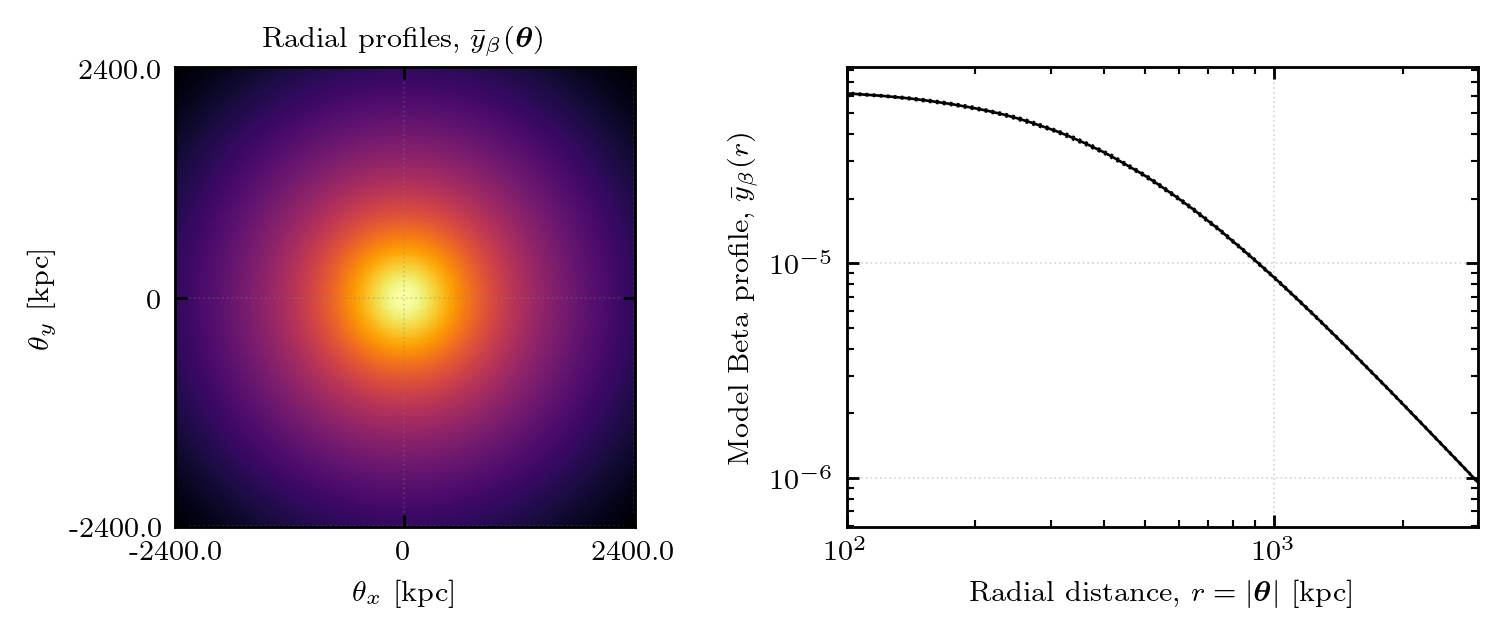

In [24]:
## Plot mean beta profile
fig, ax = plt.subplots(1,2,figsize=(7., 7./3.), dpi=256)
ax[0].imshow(ym, origin='lower', interpolation='none', cmap='inferno', norm=mpl.colors.LogNorm())
ax[1].plot(_r, ym_avg, linestyle='-', color='black', linewidth=0.75)
ax[1].plot(_r, ym_avg-ym_std, linestyle=':', color='black', linewidth=0.75)
ax[1].plot(_r, ym_avg+ym_std, linestyle=':', color='black', linewidth=0.75)
plotting.pretty_axes(ax[0])
plotting.pretty_axes(ax[1])
ax[0].set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_ylabel(r'$\theta_y$ [kpc]')
ax[0].set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_xlabel(r'$\theta_x$ [kpc]')
ax[0].set_title(r'Radial profiles, $\bar{y}_{\beta}(\boldsymbol{\theta})$', fontsize=8.)
ax[1].set_xlabel(r'Radial distance, $r = |\boldsymbol{\theta}|$ [kpc]')
ax[1].set_ylabel(r'Model Beta profile, $\bar{y}_{\beta}(r)$')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim((100, 3000))

In [25]:
## Make model for fluctuations
# Effective injection scale and effective dissipation scale
ki, kd = (5.*dk, 500.*dk)
# What we want the value to be at the peak of the amplitude spectrum (approximately)
p = 0.2
# Modal/angle-averaged spectrum powerlaw
alpha = 11./3.
## Generate fluctuations
yf = fbm.create_fbm(grid_dims, phys_dims, (-alpha,), gfunc='pow_exp', func_kwargs={'breaks': (ki, kd)}, A=p**2)
yf = ym*yf
_r, yf_avg, _ = statistics_base.bin_data(r, yf, np.nanmean)

/home/m/Documents/my_libs/Kea/Kea/utils/funcs.py:114: RuntimeWarning: divide by zero encountered in power
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/my_libs/Kea/Kea/utils/funcs.py:114: RuntimeWarning: divide by zero encountered in divide
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/my_libs/Kea/Kea/utils/funcs.py:114: RuntimeWarning: invalid value encountered in multiply
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)


-1.9921783151551514e-05 2.458766476072434e-05 -6.666542287868185e-09 1.7794223213664364e-06


Text(0.5, 1.0, '$\\delta y(\\boldsymbol{\\theta})$')

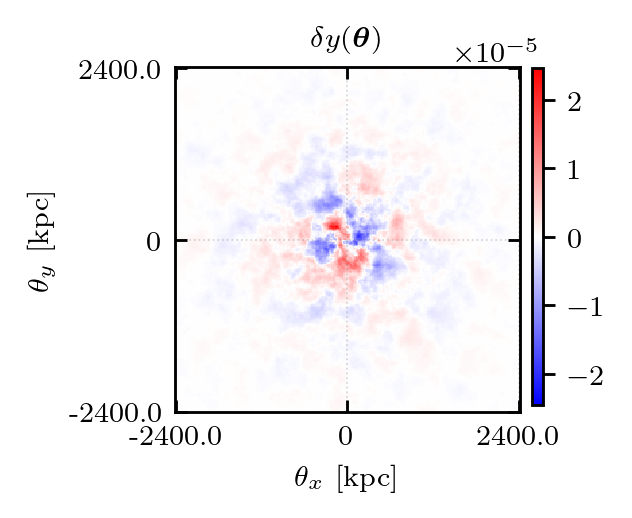

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75), dpi=256)
print(np.min(yf), np.max(yf), np.mean(yf), np.std(yf))
cmin, cmax = plotting.get_minmax(yf)
im = ax.imshow(yf, interpolation='none', origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
plotting.pretty_axes(ax)
ax.set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax.set_ylabel(r'$\theta_y$ [kpc]')
ax.set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax.set_xlabel(r'$\theta_x$ [kpc]')
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.925, 0.125, 0.025, 0.7525])
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
ax.set_title(r'$\delta y(\boldsymbol{\theta})$', fontsize=8.)

In [27]:
## Make observed field
yobs = ym + yf
_r, yobs_avg, _ = statistics_base.bin_data(r, yobs, np.nanmean)
_r, yobs_std, _ = statistics_base.bin_data(r, yobs, np.nanstd)

-0.7963377882391557 0.7020353225990374


(100, 2000)

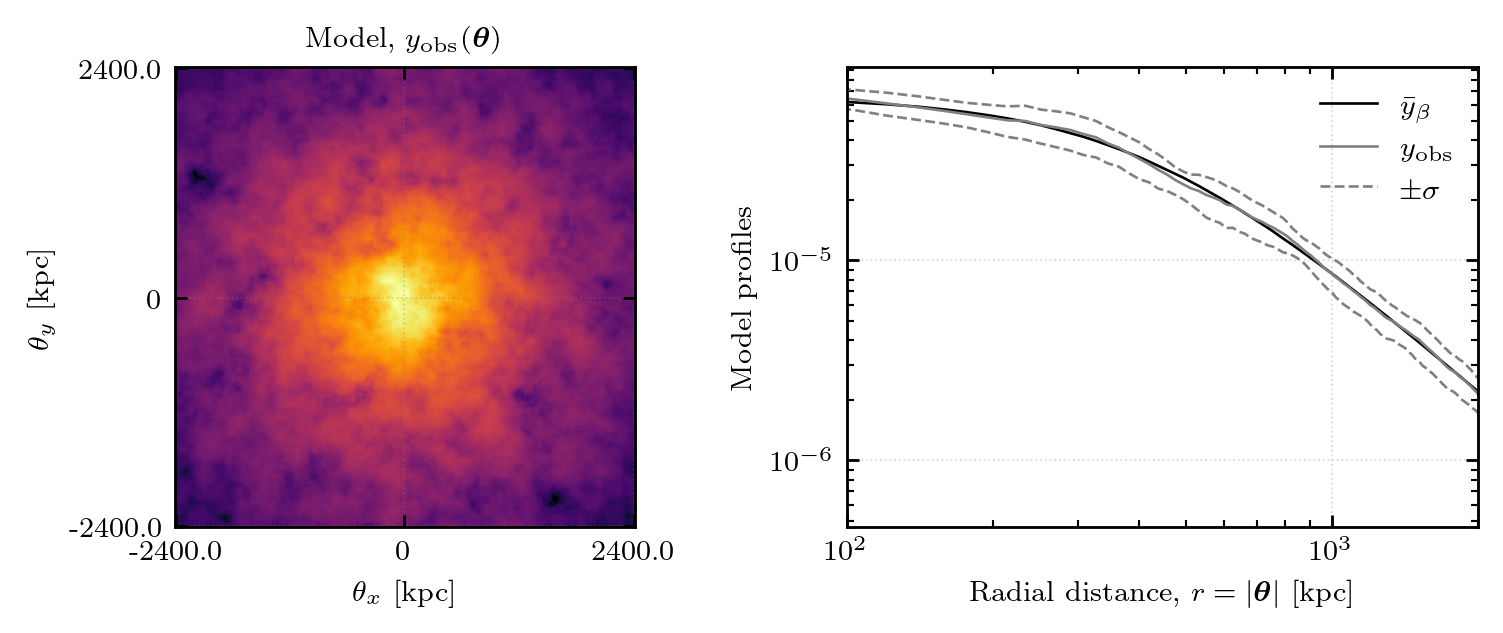

In [28]:
## Plot mean profile
fig, ax = plt.subplots(1,2,figsize=(7., 7./3.), dpi=256)
print(np.min(yf/ym), np.max(yf/ym))
cmin, cmax = plotting.get_minmax(yobs)
ax[0].imshow(yobs, origin='lower', interpolation='none', cmap='inferno', norm=mpl.colors.LogNorm())
ax[1].plot(_r, ym_avg, linestyle='-', color='black', linewidth=0.75, label=r'$\bar{y}_{\beta}$')
ax[1].plot(_r, yobs_avg, linestyle='-', color='gray', linewidth=0.75, label=r'$y_{\mathrm{obs}}$')
ax[1].plot(_r, yobs_avg-yobs_std, linestyle='--', color='gray', linewidth=0.75, label=r'$\pm \sigma$')
ax[1].plot(_r, yobs_avg+yobs_std, linestyle='--', color='gray', linewidth=0.75)
ax[1].legend(fancybox=False, frameon=False)
plotting.pretty_axes(ax[0])
plotting.pretty_axes(ax[1])
ax[0].set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_ylabel(r'$\theta_y$ [kpc]')
ax[0].set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_xlabel(r'$\theta_x$ [kpc]')
ax[0].set_title(r'Model, $y_{\mathrm{obs}}(\boldsymbol{\theta})$', fontsize=8.)
ax[1].set_xlabel(r'Radial distance, $r = |\boldsymbol{\theta}|$ [kpc]')
ax[1].set_ylabel(r'Model profiles')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim((100, 2000))

In [29]:
## Calculate amplitude spectrum
from Kea.statistics.spectra import per_spectra
# Modal spectrum
kvec, fekm = per_spectra.modal_spectrum(yf/ym, phys_dims=phys_dims)
# Angle-integrated spectrum
ko, feko, wo = spectra_base.spectrum_integrate(kvec, fekm*(dk/twopi)**D, lenn=phys_dims)
# Amplitude spectrum
feka = np.sqrt(ko*feko)

Text(0.5, 0, 'Wavenumber, $k$ [kpc$^{-1}$]')

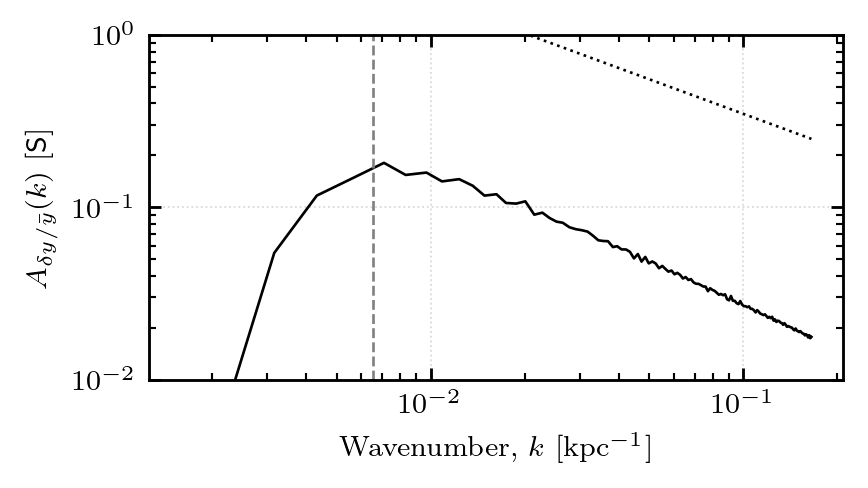

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.plot(ko, feka, linestyle='-', linewidth=0.75, color='black')
ax.axvline(ki, linestyle='--', color='gray', linewidth=0.75)
if kd <= np.max(ko):
    ax.axvline(kd, linestyle='--', color='gray', linewidth=0.75)
ax.plot(ko, 7.5e-2*ko**(-2./3.), linestyle=':', color='black', linewidth=0.75)
plotting.pretty_axes(ax)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((1e-2, 1e0))
# The amplitude spectrum is in units of the signal [`S`]. Since delta-y/bar-y is dimensionless, then so is the amplitude spectrum.
ax.set_ylabel(r'$A_{\delta y/\bar{y}}(k)$ [\textsf{S}]')
ax.set_xlabel(r'Wavenumber, $k$ [kpc$^{-1}$]')